In [1]:
!pip install torch transformers datasets rouge-score bert-score evaluate nltk

  Using cached matplotlib-3.10.6-cp311-cp311-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.59.2-cp311-cp311-macosx_10_9_universal2.whl.metadata (109 kB)
  Using cached kiwisolver-1.4.9-cp311-cp311-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
Using cached matplotlib-3.10.6-cp311-cp311-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl (270 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.59.2-cp311-cp311-macosx_10_9_universal2.whl (2.8 MB)
Using cached kiwisolver-1.4.9-cp311-cp311-macosx_11_0_arm64.whl (65 kB)
Using cached pyparsing-3.2.3-py3-none-any.whl (111 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [bert-score]7 [matplotlib]


In [3]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    pipeline
)
import evaluate
import nltk
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')

/Users/tanishapriya/Desktop/Capstone/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/tanishapriya/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/tanishapriya/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
# Bio_ClinicalBERT as encoder
biobert_model = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
biobert_tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

# T5-small as summarizer
summarizer_model = AutoModelForSeq2SeqLM.from_pretrained("t5-small")
summarizer_tokenizer = AutoTokenizer.from_pretrained("t5-small")


In [5]:
def biobert_encode(text, tokenizer, model, max_len=512):
    """Encode clinical note into embeddings using BioBERT"""
    inputs = tokenizer(
        text, return_tensors="pt", truncation=True, padding="max_length", max_length=max_len
    )
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state  # contextual embeddings


def generate_summary(text, tokenizer, model, max_len=512, summary_len=100):
    """Generate abstractive summary using T5"""
    inputs = tokenizer(
        "summarize: " + text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=max_len,
    )
    summary_ids = model.generate(
        inputs["input_ids"],
        num_beams=4,
        length_penalty=2.0,
        max_length=summary_len,
        min_length=30,
        early_stopping=True,
    )
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)



In [6]:
# Step 5: Example Input
# ============================
clinical_note = """
Patient is a 65-year-old male admitted after a fall at home. Presented with a right hip fracture 
and mild head trauma. Underwent successful open reduction and internal fixation of the hip. 
Post-op vitals stable, pain controlled with acetaminophen. No neurological deficits observed. 
Physical therapy initiated on day 2 post-op. Patient discharged in stable condition with 
recommendations for follow-up and continued physiotherapy.
"""

summary = generate_summary(clinical_note, summarizer_tokenizer, summarizer_model)
print("Original Note:\n", clinical_note)
print("\n Generated Summary:\n", summary)


Original Note:
 
Patient is a 65-year-old male admitted after a fall at home. Presented with a right hip fracture 
and mild head trauma. Underwent successful open reduction and internal fixation of the hip. 
Post-op vitals stable, pain controlled with acetaminophen. No neurological deficits observed. 
Physical therapy initiated on day 2 post-op. Patient discharged in stable condition with 
recommendations for follow-up and continued physiotherapy.


 Generated Summary:
 patient is a 65-year-old male admitted after a fall at home. Presented with a right hip fracture and mild head trauma. underwent successful open reduction and internal fixation of the hip.


In [ ]:
# Step 6: Evaluation
# ============================

# Load metrics
rouge = evaluate.load("rouge")
bertscore = evaluate.load("bertscore")

reference_summary = """65-year-old male with hip fracture and mild head trauma. 
Successful surgery, stable recovery, started physiotherapy, discharged with follow-up advice."""

# ROUGE Scores
rouge_results = rouge.compute(
    predictions=[summary], references=[reference_summary]
)
print("\n📊 ROUGE Results:", rouge_results)

# BERTScore
bert_results = bertscore.compute(
    predictions=[summary], references=[reference_summary], lang="en"
)
print("\n📊 BERTScore Results:", bert_results)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



📊 ROUGE Results: {'rouge1': np.float64(0.43636363636363634), 'rouge2': np.float64(0.3018867924528302), 'rougeL': np.float64(0.43636363636363634), 'rougeLsum': np.float64(0.43636363636363634)}


In [6]:
from transformers import pipeline

# 1. Load summarization pipeline (you can use "t5-small" or "facebook/bart-large-cnn")
summarizer = pipeline("summarization", model="t5-small", tokenizer="t5-small")

# 2. Sample clinical note input
clinical_note = """
Patient is a 65-year-old male admitted after a fall at home. 
Presented with a right hip fracture and mild head trauma. 
Underwent successful open reduction and internal fixation of the hip. 
Post-op vitals stable, pain controlled with acetaminophen. 
No neurological deficits observed. Physical therapy initiated on day 2 post-op.
"""

# 3. Generate summary
result = summarizer(clinical_note, max_length=60, min_length=20, do_sample=False)
summary = result[0]['summary_text']
print("📝 Summary:\n", summary)
# 7. Readability (Flesch Reading Ease)
import re

def flesch_reading_ease(text):
    sentences = re.split(r'[.!?]+', text)
    words = text.split()
    syllables = sum([sum(ch in "aeiouAEIOU" for ch in word) for word in words])
    ASL = len(words) / max(1, len(sentences))  # Average Sentence Length
    ASW = syllables / max(1, len(words))       # Average Syllables per Word
    FRE = 206.835 - (1.015 * ASL) - (84.6 * ASW)
    return round(FRE, 2)

readability = flesch_reading_ease(summary)
print("\n📊 Readability (Flesch Score):", readability)


/Users/tanishapriya/Desktop/Capstone/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use mps:0
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


📝 Summary:
 patient is 65-year-old male admitted after a fall at home . underwent successful open reduction and internal fixation of the hip .

📊 Readability (Flesch Score): 37.88


In [2]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


Device set to use mps:0
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Your max_length is set to 60, but your input_length is only 56. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=28)
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classe

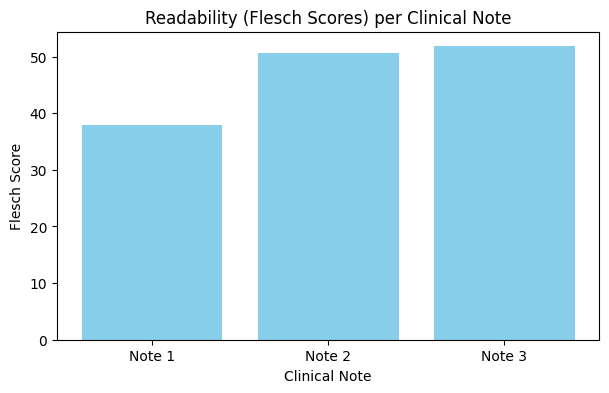

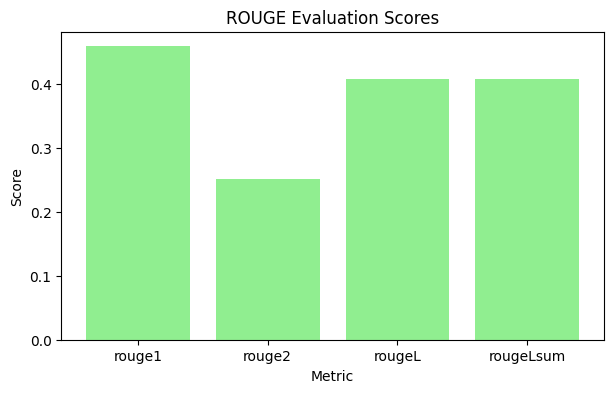

In [6]:
import matplotlib.pyplot as plt
import re
import evaluate
from transformers import pipeline

# 1. Load summarizer
summarizer = pipeline("summarization", model="t5-small", tokenizer="t5-small")

# 2. Clinical notes + references
clinical_notes = [
    """Patient is a 65-year-old male admitted after a fall at home. 
    Presented with a right hip fracture and mild head trauma. 
    Underwent successful open reduction and internal fixation of the hip. 
    Post-op vitals stable, pain controlled with acetaminophen. 
    No neurological deficits observed. Physical therapy initiated on day 2 post-op.""",

    """Patient is a 58-year-old female with history of diabetes and hypertension. 
    Admitted with chest pain and shortness of breath. 
    ECG showed ST-elevation, diagnosed with myocardial infarction. 
    Underwent angioplasty successfully. Stable post-procedure.""",

    """Patient is a 72-year-old male with chronic kidney disease. 
    Admitted due to weakness and swelling in legs. 
    Lab tests show high creatinine and low hemoglobin. 
    Hemodialysis initiated. Patient advised renal diet and follow-up."""
]

references = [
    "65-year-old male with hip fracture and mild head trauma underwent surgery, stable recovery with physiotherapy.",
    "58-year-old female with diabetes and hypertension had a heart attack, angioplasty performed, stable post-op.",
    "72-year-old male with kidney disease admitted for weakness, started dialysis and advised renal diet."
]

# 3. Readability
def flesch_reading_ease(text):
    sentences = re.split(r'[.!?]+', text)
    words = text.split()
    syllables = sum([sum(ch in "aeiouAEIOU" for ch in word) for word in words])
    ASL = len(words) / max(1, len(sentences))  
    ASW = syllables / max(1, len(words))       
    FRE = 206.835 - (1.015 * ASL) - (84.6 * ASW)
    return round(FRE, 2)

# 4. Summarize + evaluate
generated_summaries = []
readability_scores = []
rouge = evaluate.load("rouge")

for note in clinical_notes:
    result = summarizer(note, max_length=60, min_length=20, do_sample=False)
    summary = result[0]['summary_text']
    generated_summaries.append(summary)
    readability_scores.append(flesch_reading_ease(summary))

rouge_result = rouge.compute(predictions=generated_summaries, references=references)

# 5. Visualization
plt.figure(figsize=(7,4))
plt.bar([f"Note {i+1}" for i in range(len(readability_scores))], readability_scores, color="skyblue")
plt.title("Readability (Flesch Scores) per Clinical Note")
plt.ylabel("Flesch Score")
plt.xlabel("Clinical Note")
plt.show()

# Convert ROUGE scores
rouge_scores = {k: float(v) for k, v in rouge_result.items()}

# Plot ROUGE scores
plt.figure(figsize=(7,4))
plt.bar(list(rouge_scores.keys()), list(rouge_scores.values()), color="lightgreen")
plt.title("ROUGE Evaluation Scores")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.show()

In [5]:
import pandas as pd
from transformers import pipeline
import evaluate
import re

# -----------------------------
# 1. Helper: Readability Score
# -----------------------------
def flesch_reading_ease(text):
    sentences = re.split(r'[.!?]+', text)
    words = text.split()
    syllables = sum([sum(ch in "aeiouAEIOU" for ch in word) for word in words])
    ASL = len(words) / max(1, len(sentences))  # Avg Sentence Length
    ASW = syllables / max(1, len(words))       # Avg Syllables per Word
    FRE = 206.835 - (1.015 * ASL) - (84.6 * ASW)
    return round(FRE, 2)

# -----------------------------
# 2. Load summarizer and metric
# -----------------------------
summarizer = pipeline("summarization", model="t5-small", tokenizer="t5-small")
rouge = evaluate.load("rouge")

# -----------------------------
# 3. Clinical Notes Dataset
# -----------------------------
clinical_notes = [
    """Patient is a 65-year-old male admitted after a fall at home. Presented with a right hip fracture and mild head trauma. Underwent successful open reduction and internal fixation of the hip. Post-op vitals stable, pain controlled with acetaminophen. Physical therapy initiated on day 2 post-op.""",
    
    """Patient is a 54-year-old female with a history of uncontrolled diabetes mellitus, admitted with non-healing foot ulcer. Started on IV antibiotics and wound debridement performed. Blood glucose managed with insulin infusion. Patient showing signs of improvement.""",
    
    """Patient presented with chest pain and shortness of breath. ECG revealed ST elevation in anterior leads. Immediate thrombolysis was done and dual antiplatelet therapy started. Patient is hemodynamically stable and kept under observation in ICU."""
]

# -----------------------------
# 4. Run summarization + metrics
# -----------------------------
results = []

for note in clinical_notes:
    summary = summarizer(note, max_length=60, min_length=20, do_sample=False)[0]['summary_text']
    readability = flesch_reading_ease(summary)
    rouge_result = rouge.compute(predictions=[summary], references=[note])
    rouge_scores = {k: round(float(v), 3) for k, v in rouge_result.items()}
    
    results.append({
        "Clinical Note": note[:80] + "...",  # shorten for table
        "Generated Summary": summary,
        "Readability (FRE)": readability,
        "ROUGE-1": rouge_scores['rouge1'],
        "ROUGE-2": rouge_scores['rouge2'],
        "ROUGE-L": rouge_scores['rougeL']
    })

# -----------------------------
# 5. Convert to DataFrame
# -----------------------------
df = pd.DataFrame(results)
print(df)

# Optionally save to CSV for your paper
df.to_csv("results_table.csv", index=False)

Device set to use mps:0
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Your max_length is set to 60, but your input_length is only 54. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=27)
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classe

                                       Clinical Note  \
0  Patient is a 65-year-old male admitted after a...   
1  Patient is a 54-year-old female with a history...   
2  Patient presented with chest pain and shortnes...   

                                   Generated Summary  Readability (FRE)  \
0  patient is a 65-year-old male admitted after a...              40.89   
1  patient is a 54-year-old female with a history...              22.50   
2  patient presented with chest pain and shortnes...              45.65   

   ROUGE-1  ROUGE-2  ROUGE-L  
0    0.639    0.600    0.639  
1    0.721    0.678    0.721  
2    0.627    0.612    0.627  


Device set to use mps:0
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Your max_length is set to 60, but your input_length is only 54. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=27)
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classe

       ID                                      Clinical Note  \
0  Note 1  Patient is a 65-year-old male admitted after a...   
1  Note 2  Patient is a 54-year-old female with a history...   
2  Note 3  Patient presented with chest pain and shortnes...   

                                   Generated Summary  Readability (FRE)  \
0  patient is a 65-year-old male admitted after a...              40.89   
1  patient is a 54-year-old female with a history...              22.50   
2  patient presented with chest pain and shortnes...              45.65   

   ROUGE-1  ROUGE-2  ROUGE-L  
0    0.639    0.600    0.639  
1    0.721    0.678    0.721  
2    0.627    0.612    0.627  


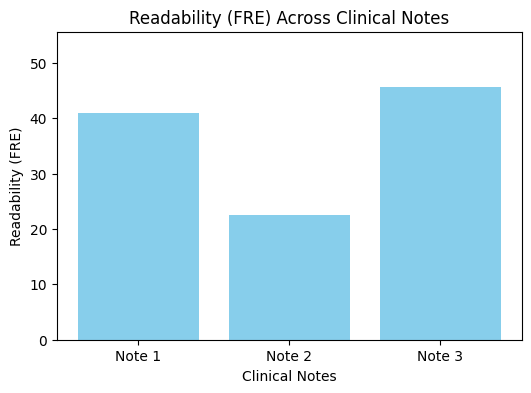

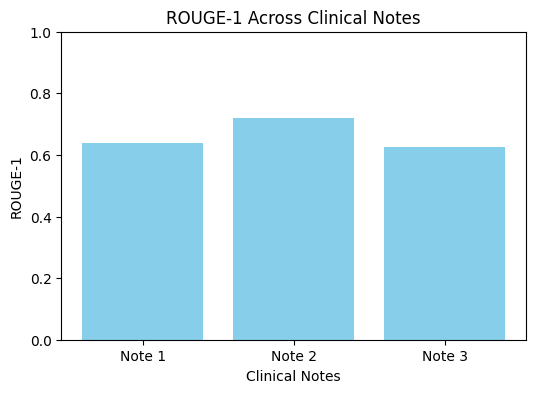

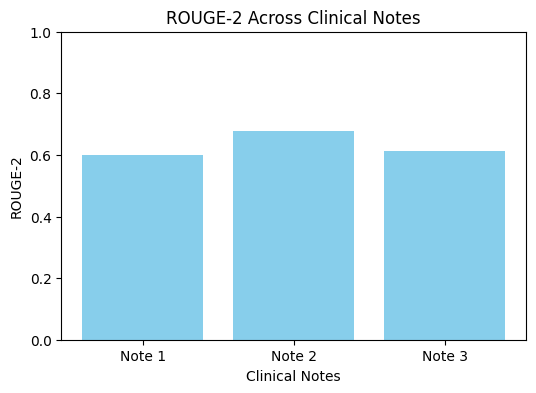

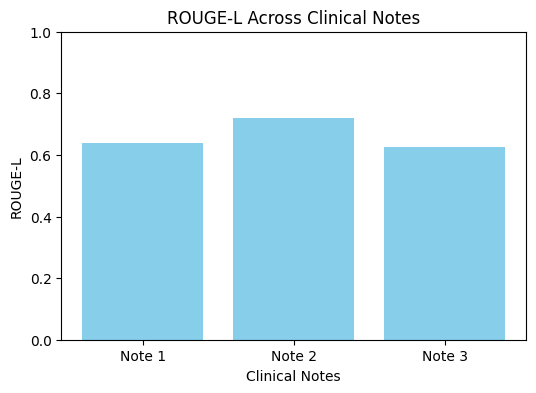

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline
import evaluate
import re

# -----------------------------
# 1. Helper: Readability Score
# -----------------------------
def flesch_reading_ease(text):
    sentences = re.split(r'[.!?]+', text)
    words = text.split()
    syllables = sum([sum(ch in "aeiouAEIOU" for ch in word) for word in words])
    ASL = len(words) / max(1, len(sentences))  # Avg Sentence Length
    ASW = syllables / max(1, len(words))       # Avg Syllables per Word
    FRE = 206.835 - (1.015 * ASL) - (84.6 * ASW)
    return round(FRE, 2)

# -----------------------------
# 2. Load summarizer and metric
# -----------------------------
summarizer = pipeline("summarization", model="t5-small", tokenizer="t5-small")
rouge = evaluate.load("rouge")

# -----------------------------
# 3. Clinical Notes Dataset
# -----------------------------
clinical_notes = [
    """Patient is a 65-year-old male admitted after a fall at home. Presented with a right hip fracture and mild head trauma. Underwent successful open reduction and internal fixation of the hip. Post-op vitals stable, pain controlled with acetaminophen. Physical therapy initiated on day 2 post-op.""",
    
    """Patient is a 54-year-old female with a history of uncontrolled diabetes mellitus, admitted with non-healing foot ulcer. Started on IV antibiotics and wound debridement performed. Blood glucose managed with insulin infusion. Patient showing signs of improvement.""",
    
    """Patient presented with chest pain and shortness of breath. ECG revealed ST elevation in anterior leads. Immediate thrombolysis was done and dual antiplatelet therapy started. Patient is hemodynamically stable and kept under observation in ICU."""
]

# -----------------------------
# 4. Run summarization + metrics
# -----------------------------
results = []

for i, note in enumerate(clinical_notes):
    summary = summarizer(note, max_length=60, min_length=20, do_sample=False)[0]['summary_text']
    readability = flesch_reading_ease(summary)
    rouge_result = rouge.compute(predictions=[summary], references=[note])
    rouge_scores = {k: round(float(v), 3) for k, v in rouge_result.items()}
    
    results.append({
        "ID": f"Note {i+1}",
        "Clinical Note": note[:80] + "...",  # shorten for table
        "Generated Summary": summary,
        "Readability (FRE)": readability,
        "ROUGE-1": rouge_scores['rouge1'],
        "ROUGE-2": rouge_scores['rouge2'],
        "ROUGE-L": rouge_scores['rougeL']
    })

# -----------------------------
# 5. Convert to DataFrame
# -----------------------------
df = pd.DataFrame(results)
print(df)

# Save to CSV
df.to_csv("results_table.csv", index=False)

# -----------------------------
# 6. Visualization
# -----------------------------
metrics = ["Readability (FRE)", "ROUGE-1", "ROUGE-2", "ROUGE-L"]

for metric in metrics:
    plt.figure(figsize=(6,4))
    plt.bar(df["ID"], df[metric], color="skyblue")
    plt.title(f"{metric} Across Clinical Notes")
    plt.xlabel("Clinical Notes")
    plt.ylabel(metric)
    plt.ylim(0, max(df[metric]) + 10 if "Readability" in metric else 1)  # FRE can exceed 100
    plt.show()